In [1]:
# ============================================================================
# CTAB-GAN with Differential Privacy, KL/JS Divergence, and Bug Fixes
# ============================================================================

import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.nn.utils import spectral_norm, clip_grad_norm_
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from dataclasses import dataclass
from typing import Optional, Callable
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency, entropy
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

# Load your data
data_path = "/kaggle/input/datasets/toshangupta/adult-dataset/adult.csv"  # Update path
df = pd.read_csv(data_path)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
print(f"Loaded data: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded data: (45222, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [3]:
# ============================================================================
# 2. TYPE INFERENCE AND PREPROCESSING
# ============================================================================
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)
cat_cols = list(df.select_dtypes(include=['object']).columns)
print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

Numeric columns (6): ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns (9): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


In [4]:
# ============================================================================
# 3. CONDITIONAL VECTOR CREATION
# ============================================================================

# Select a subset of categorical columns for conditioning
# You can also use numeric columns or all columns
cond_cols = cat_cols[:min(3, len(cat_cols))]  # Use first 3 categorical columns
print(f"Conditioning on: {cond_cols}")

# Create one-hot encoded conditional vectors
if cond_cols:
    cond_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    cond_full = cond_encoder.fit_transform(df[cond_cols])
    cond_dim = cond_full.shape[1]
else:
    cond_full = np.zeros((len(df), 1))
    cond_dim = 1

print(f"Conditional dimension: {cond_dim}")

Conditioning on: ['workclass', 'education', 'marital-status']
Conditional dimension: 30


In [5]:
# ============================================================================
# 4. DATA TRANSFORMATION PIPELINE
# ============================================================================

class ToRangeMinus1To1(BaseEstimator, TransformerMixin):
    """Transform from [0,1] to [-1,1] range"""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return 2.0 * X - 1.0
    def inverse_transform(self, X):
        return (X + 1.0) / 2.0

# Numeric pipeline: QuantileTransform -> [-1, 1]
num_pipe = Pipeline([
    ("qt", QuantileTransformer(output_distribution="uniform", random_state=0)),
    ("rng", ToRangeMinus1To1())
])

# Categorical pipeline: OneHotEncoder
cat_pipe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Combined preprocessor
pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

# Fit and transform
X_proc = pre.fit_transform(df)
print(f"Processed shape: {X_proc.shape}")
print(f"Processed range: [{X_proc.min():.3f}, {X_proc.max():.3f}]")

Processed shape: (45222, 106)
Processed range: [-1.000, 1.000]


In [6]:
# ============================================================================
# 5. CONDITIONAL SAMPLER
# ============================================================================

def cond_sampler(batch_size: int) -> torch.Tensor:
    """Sample random conditional vectors"""
    idx = np.random.randint(0, X_proc.shape[0], size=batch_size)
    return torch.tensor(cond_full[idx], dtype=torch.float32)

# Convert to torch tensor
real_tensor = torch.tensor(X_proc, dtype=torch.float32)
input_dim = real_tensor.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 106


In [7]:
# ============================================================================
# 6. GAN ARCHITECTURE WITH SPECTRAL NORMALIZATION
# ============================================================================

def orthogonal_init(m: nn.Module):
    """Initialize weights with orthogonal initialization"""
    if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

class SpectralLinear(nn.Module):
    """Linear layer with spectral normalization"""
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.lin = spectral_norm(nn.Linear(in_features, out_features, bias=bias))
    
    def forward(self, x):
        return self.lin(x)

class LayerBlock(nn.Module):
    """Basic building block with optional spectral normalization"""
    def __init__(self, in_f, out_f, use_sn: bool = False, dropout: float = 0.0):
        super().__init__()
        self.fc = SpectralLinear(in_f, out_f) if use_sn else nn.Linear(in_f, out_f)
        self.ln = nn.LayerNorm(out_f)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
    
    def forward(self, x):
        x = self.fc(x)
        x = self.ln(x)
        x = self.act(x)
        x = self.dropout(x)
        return x

class Generator(nn.Module):
    """Generator network"""
    def __init__(self, noise_dim: int, cond_dim: int, out_dim: int, 
                 hidden: int = 128, num_layers: int = 3, dropout: float = 0.0):
        super().__init__()
        in_dim = noise_dim + cond_dim
        layers = [LayerBlock(in_dim, hidden, use_sn=False, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(LayerBlock(hidden, hidden, use_sn=False, dropout=dropout))
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(hidden, out_dim)
        self.final_act = nn.Tanh()  # Tanh to constrain output to [-1, 1]
        self.apply(orthogonal_init)
    
    def forward(self, z, cond):
        x = torch.cat([z, cond], dim=1)
        x = self.mlp(x)
        x = self.out(x)
        return self.final_act(x)

class Critic(nn.Module):
    """Critic (Discriminator) network with spectral normalization"""
    def __init__(self, in_dim: int, hidden: int = 128, num_layers: int = 3, dropout: float = 0.0):
        super().__init__()
        layers = [LayerBlock(in_dim, hidden, use_sn=True, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(LayerBlock(hidden, hidden, use_sn=True, dropout=dropout))
        self.mlp = nn.Sequential(*layers)
        self.out = SpectralLinear(hidden, 1)
        self.apply(orthogonal_init)
    
    def forward(self, x):
        x = self.mlp(x)
        return self.out(x)

In [8]:
# ============================================================================
# 7. DIFFERENTIAL PRIVACY IMPLEMENTATION
# ============================================================================

class DifferentialPrivacyEngine:
    """
    Implements Differential Privacy using DP-SGD
    References:
    - Abadi et al. (2016): Deep Learning with Differential Privacy
    - https://arxiv.org/abs/1607.00133
    """
    def __init__(self, noise_multiplier: float = 1.0, max_grad_norm: float = 1.0):
        self.noise_multiplier = noise_multiplier
        self.max_grad_norm = max_grad_norm
        self.steps = 0
    
    def clip_and_accumulate_gradients(self, model: nn.Module, per_sample_grads):
        """
        Clip per-sample gradients and accumulate
        """
        # Clip each sample's gradient
        clipped_grads = []
        for grad in per_sample_grads:
            grad_norm = grad.norm(2)
            clip_coef = min(1.0, self.max_grad_norm / (grad_norm + 1e-6))
            clipped_grads.append(grad * clip_coef)
        
        # Average the clipped gradients
        return torch.stack(clipped_grads).mean(dim=0)
    
    def add_noise_to_gradients(self, model: nn.Module, batch_size: int):
        """
        Add Gaussian noise to gradients for differential privacy
        """
        for param in model.parameters():
            if param.grad is not None:
                noise = torch.randn_like(param.grad) * self.noise_multiplier * self.max_grad_norm / batch_size
                param.grad += noise
        self.steps += 1
    
    def compute_epsilon(self, dataset_size: int, batch_size: int, epochs: int, delta: float = 1e-5):
        """
        Compute privacy budget (epsilon) using the moments accountant method
        This is a simplified approximation
        """
        q = batch_size / dataset_size  # Sampling ratio
        steps = (dataset_size / batch_size) * epochs
        
        # Simplified epsilon calculation (approximate)
        # For more accurate calculation, use the opacus library
        sigma = self.noise_multiplier
        epsilon = q * steps / (sigma ** 2) * np.sqrt(2 * np.log(1.25 / delta))
        
        return epsilon

In [9]:
# ============================================================================
# 8. TRAINING CONFIGURATION
# ============================================================================

@dataclass
class TrainConfig:
    input_dim: int
    cond_dim: int
    noise_dim: int = 64
    g_hidden: int = 128
    d_hidden: int = 128
    g_layers: int = 3
    d_layers: int = 3
    batch_size: int = 64
    n_epochs: int = 100
    n_critic: int = 5
    lr_g: float = 1e-4
    lr_d: float = 1e-4
    beta1: float = 0.0
    beta2: float = 0.9
    lambda_gp: float = 10.0
    grad_clip_g: float = 1.0
    grad_clip_d: float = 1.0
    inst_noise_sigma0: float = 0.1
    inst_noise_min: float = 0.0
    inst_noise_anneal: str = "exp"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    clamp_min: Optional[float] = None  # No clamping for Tanh output
    clamp_max: Optional[float] = None
    use_amp: bool = True
    seed: Optional[int] = 42
    dropout: float = 0.1
    # Differential Privacy parameters
    use_dp: bool = True
    dp_noise_multiplier: float = 0.5
    dp_max_grad_norm: float = 1.0
    dp_delta: float = 1e-5

In [10]:
# ============================================================================
# 9. HELPER FUNCTIONS
# ============================================================================

def _annealed_sigma(cfg: TrainConfig, epoch: int) -> float:
    """Anneal instance noise over training"""
    if cfg.inst_noise_sigma0 <= 0:
        return 0.0
    T = max(cfg.n_epochs - 1, 1)
    if cfg.inst_noise_anneal == "linear":
        frac = 1.0 - (epoch / T)
        return cfg.inst_noise_min + (cfg.inst_noise_sigma0 - cfg.inst_noise_min) * frac
    else:
        k = 5.0
        frac = math.exp(-k * (epoch / T))
        return cfg.inst_noise_min + (cfg.inst_noise_sigma0 - cfg.inst_noise_min) * frac

def _add_instance_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    """Add instance noise for stability"""
    if sigma <= 0:
        return x
    return x + sigma * torch.randn_like(x)

def gradient_penalty(critic: nn.Module, real: torch.Tensor, fake: torch.Tensor, device: str) -> torch.Tensor:
    """Compute gradient penalty for WGAN-GP"""
    bsz = real.size(0)
    eps = torch.rand(bsz, 1, device=device).expand(-1, real.size(1))
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    score = critic(inter)
    grad = torch.autograd.grad(outputs=score, inputs=inter,
                               grad_outputs=torch.ones_like(score),
                               create_graph=True, retain_graph=True, only_inputs=True)[0]
    grad = grad.view(bsz, -1)
    gp = ((grad.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp

@torch.no_grad()
def clamp_range(x, lo, hi):
    """Clamp values to range (if specified)"""
    if lo is None or hi is None:
        return x
    return x.clamp(lo, hi)

In [11]:
# ============================================================================
# 10. TRAINING FUNCTION WITH DIFFERENTIAL PRIVACY
# ============================================================================

def train_ctabgan_stable(real_data: torch.Tensor, cond_sampler: Callable, cfg: TrainConfig):
    """
    Train CTAB-GAN with Wasserstein loss, gradient penalty, spectral normalization,
    and optional differential privacy
    """
    if cfg.seed is not None:
        torch.manual_seed(cfg.seed)
        torch.cuda.manual_seed_all(cfg.seed)
        np.random.seed(cfg.seed)

    device = cfg.device
    N, D = real_data.shape
    assert D == cfg.input_dim, f"input_dim mismatch: data {D} vs cfg {cfg.input_dim}"
    real_data = real_data.to(device)

    # Initialize networks
    G = Generator(cfg.noise_dim, cfg.cond_dim, cfg.input_dim, 
                  hidden=cfg.g_hidden, num_layers=cfg.g_layers, dropout=cfg.dropout).to(device)
    Dnet = Critic(cfg.input_dim, hidden=cfg.d_hidden, num_layers=cfg.d_layers, dropout=cfg.dropout).to(device)

    # Optimizers
    optG = torch.optim.Adam(G.parameters(), lr=cfg.lr_g, betas=(cfg.beta1, cfg.beta2))
    optD = torch.optim.Adam(Dnet.parameters(), lr=cfg.lr_d, betas=(cfg.beta1, cfg.beta2))

    # Mixed precision scalers
    scalerG = torch.cuda.amp.GradScaler(enabled=cfg.use_amp and device.startswith("cuda"))
    scalerD = torch.cuda.amp.GradScaler(enabled=cfg.use_amp and device.startswith("cuda"))

    # Differential Privacy Engine
    dp_engine = None
    if cfg.use_dp:
        dp_engine = DifferentialPrivacyEngine(
            noise_multiplier=cfg.dp_noise_multiplier,
            max_grad_norm=cfg.dp_max_grad_norm
        )
        print(f"Training with Differential Privacy (σ={cfg.dp_noise_multiplier}, C={cfg.dp_max_grad_norm})")

    # Training history
    hist = {
        "g_loss": [],
        "d_loss": [],
        "gp": [],
        "w_dist": []  # Wasserstein distance estimate
    }

    def sample_real(b):
        idx = torch.randint(0, N, (b,), device=device)
        return real_data[idx]

    print(f"Starting training for {cfg.n_epochs} epochs...")
    
    for epoch in range(cfg.n_epochs):
        sigma = _annealed_sigma(cfg, epoch)
        n_steps = max(1, N // cfg.batch_size)
        g_epoch = 0.0
        d_epoch = 0.0
        gp_epoch = 0.0
        wd_epoch = 0.0

        for step in range(n_steps):
            # =================================================================
            # Train Critic (Discriminator)
            # =================================================================
            for _ in range(cfg.n_critic):
                x_real = sample_real(cfg.batch_size)
                if sigma > 0:
                    x_real = _add_instance_noise(x_real, sigma)

                z = torch.randn(cfg.batch_size, cfg.noise_dim, device=device)
                cond = cond_sampler(cfg.batch_size).to(device)
                
                with torch.cuda.amp.autocast(enabled=scalerD.is_enabled()):
                    x_fake = G(z, cond).detach()
                    x_fake = clamp_range(x_fake, cfg.clamp_min, cfg.clamp_max)
                    if sigma > 0:
                        x_fake = _add_instance_noise(x_fake, sigma)
                    
                    d_real = Dnet(x_real)
                    d_fake = Dnet(x_fake)
                    gp = gradient_penalty(Dnet, x_real, x_fake, device) * cfg.lambda_gp
                    d_loss = (d_fake.mean() - d_real.mean()) + gp
                    
                    # Track Wasserstein distance estimate
                    w_dist = d_real.mean() - d_fake.mean()

                optD.zero_grad(set_to_none=True)
                scalerD.scale(d_loss).backward()
                scalerD.unscale_(optD)
                
                # Gradient clipping
                if cfg.grad_clip_d and cfg.grad_clip_d > 0:
                    clip_grad_norm_(Dnet.parameters(), cfg.grad_clip_d)
                
                # Add DP noise to discriminator gradients
                if dp_engine:
                    dp_engine.add_noise_to_gradients(Dnet, cfg.batch_size)
                
                scalerD.step(optD)
                scalerD.update()
                
                d_epoch += d_loss.item()
                gp_epoch += gp.item()
                wd_epoch += w_dist.item()

            # =================================================================
            # Train Generator
            # =================================================================
            z = torch.randn(cfg.batch_size, cfg.noise_dim, device=device)
            cond = cond_sampler(cfg.batch_size).to(device)
            
            with torch.cuda.amp.autocast(enabled=scalerG.is_enabled()):
                x_fake = G(z, cond)
                x_fake = clamp_range(x_fake, cfg.clamp_min, cfg.clamp_max)
                g_loss = -Dnet(x_fake).mean()

            optG.zero_grad(set_to_none=True)
            scalerG.scale(g_loss).backward()
            scalerG.unscale_(optG)
            
            # Gradient clipping
            if cfg.grad_clip_g and cfg.grad_clip_g > 0:
                clip_grad_norm_(G.parameters(), cfg.grad_clip_g)
            
            scalerG.step(optG)
            scalerG.update()
            
            g_epoch += g_loss.item()

        # Store epoch statistics
        hist["g_loss"].append(g_epoch / n_steps)
        hist["d_loss"].append(d_epoch / (n_steps * cfg.n_critic))
        hist["gp"].append(gp_epoch / (n_steps * cfg.n_critic))
        hist["w_dist"].append(wd_epoch / (n_steps * cfg.n_critic))

        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{cfg.n_epochs}] | "
                  f"G Loss: {hist['g_loss'][-1]:.4f} | "
                  f"D Loss: {hist['d_loss'][-1]:.4f} | "
                  f"GP: {hist['gp'][-1]:.4f} | "
                  f"W-Dist: {hist['w_dist'][-1]:.4f} | "
                  f"σ_inst: {sigma:.4f}")

    # Compute privacy budget if using DP
    if dp_engine:
        epsilon = dp_engine.compute_epsilon(N, cfg.batch_size, cfg.n_epochs, cfg.dp_delta)
        print(f"\nPrivacy Budget: ε = {epsilon:.2f} (δ = {cfg.dp_delta})")
        hist["epsilon"] = epsilon
        hist["delta"] = cfg.dp_delta

    G.eval()
    Dnet.eval()
    
    return {
        "G": G,
        "D": Dnet,
        "history": hist,
        "config": cfg,
        "dp_engine": dp_engine
    }

In [12]:
# ============================================================================
# 11. SYNTHETIC DATA GENERATION AND INVERSE TRANSFORM
# ============================================================================

@torch.no_grad()
def sample_synth(G, cond_sampler, cfg, n=1000):
    """Generate synthetic samples"""
    G.eval()
    z = torch.randn(n, cfg.noise_dim, device=cfg.device)
    cond = cond_sampler(n).to(cfg.device)
    x = G(z, cond).cpu().numpy()
    return x

def inverse_transform_fixed(pre, X_proc, df_template):
    """
    Fixed inverse transform that properly handles the data
    
    FIXES THE ZERO VALUES BUG:
    1. Properly clips values before inverse transform
    2. Handles edge cases in quantile transform
    3. Correctly reconstructs categorical variables
    """
    # Get column information
    num_cols = pre.transformers_[0][2] if len(pre.transformers_) > 0 else []
    cat_cols = pre.transformers_[1][2] if len(pre.transformers_) > 1 else []
    
    # Get fitted transformers
    num_transformer = pre.named_transformers_.get("num") if len(num_cols) > 0 else None
    cat_transformer = pre.named_transformers_.get("cat") if len(cat_cols) > 0 else None
    
    out = pd.DataFrame(index=range(X_proc.shape[0]))
    start = 0
    
    # =========================================================================
    # Inverse transform NUMERIC columns
    # =========================================================================
    if len(num_cols) > 0 and num_transformer is not None:
        num_dim = len(num_cols)
        Xn = X_proc[:, start:start+num_dim]
        start += num_dim
        
        # Get the QuantileTransformer
        qt = num_transformer.named_steps["qt"]
        to_range = num_transformer.named_steps["rng"]
        
        # Inverse transform: [-1,1] -> [0,1]
        Xn_uniform = to_range.inverse_transform(Xn)
        
        # Clip to valid range to avoid numerical issues
        Xn_uniform = np.clip(Xn_uniform, 1e-7, 1 - 1e-7)
        
        # Inverse quantile transform
        Xn_inv = qt.inverse_transform(Xn_uniform)
        
        # Assign to dataframe
        out[num_cols] = Xn_inv
    
    # =========================================================================
    # Inverse transform CATEGORICAL columns
    # =========================================================================
    if len(cat_cols) > 0 and cat_transformer is not None:
        # Get one-hot dimension
        oh_dim = cat_transformer.transform(df_template[cat_cols].iloc[:1]).shape[1]
        Xc = X_proc[:, start:start+oh_dim]
        start += oh_dim
        
        # Get categories for each column
        cats = cat_transformer.categories_
        col_ptr = 0
        
        for col, cats_list in zip(cat_cols, cats):
            k = len(cats_list)
            block = Xc[:, col_ptr:col_ptr+k]
            
            # Apply softmax to convert to probabilities, then argmax
            # This handles cases where the network outputs aren't properly normalized
            block_softmax = np.exp(block) / np.exp(block).sum(axis=1, keepdims=True)
            idx = block_softmax.argmax(axis=1)
            
            out[col] = np.array(cats_list)[idx]
            col_ptr += k
    
    # Reorder columns to match original
    out = out[df_template.columns]
    
    return out


In [13]:
# ============================================================================
# 13. MAIN TRAINING EXECUTION
# ============================================================================

print("\n" + "="*80)
print("TRAINING CTAB-GAN WITH DIFFERENTIAL PRIVACY")
print("="*80 + "\n")

cfg = TrainConfig(
    input_dim=input_dim,
    cond_dim=cond_dim,
    noise_dim=64,
    g_hidden=128,
    d_hidden=128,
    g_layers=3,
    d_layers=3,
    batch_size=64,
    n_epochs=100,  # Increase for better results
    n_critic=5,
    lr_g=1e-4,
    lr_d=1e-4,
    beta1=0.0,
    beta2=0.9,
    lambda_gp=10.0,
    grad_clip_g=1.0,
    grad_clip_d=1.0,
    inst_noise_sigma0=0.1,
    inst_noise_min=0.0,
    inst_noise_anneal="exp",
    clamp_min=None,  # No clamping with Tanh
    clamp_max=None,
    use_amp=True,
    seed=42,
    dropout=0.1,
    # Differential Privacy settings
    use_dp=True,  # Set to False to disable DP
    dp_noise_multiplier=0.5,  # Lower = less privacy, better utility
    dp_max_grad_norm=1.0,
    dp_delta=1e-5
)

# Train the model
result = train_ctabgan_stable(real_tensor, cond_sampler, cfg)
G, D = result["G"], result["D"]

print(f"\nTraining complete!")
print(f"Final Generator Loss: {result['history']['g_loss'][-1]:.4f}")
print(f"Final Discriminator Loss: {result['history']['d_loss'][-1]:.4f}")
print(f"Final Wasserstein Distance: {result['history']['w_dist'][-1]:.4f}")


TRAINING CTAB-GAN WITH DIFFERENTIAL PRIVACY

Training with Differential Privacy (σ=0.5, C=1.0)
Starting training for 100 epochs...
Epoch [1/100] | G Loss: -1.7106 | D Loss: -0.4827 | GP: 0.2336 | W-Dist: 0.7163 | σ_inst: 0.1000
Epoch [10/100] | G Loss: -1.9493 | D Loss: -0.2472 | GP: 0.0743 | W-Dist: 0.3215 | σ_inst: 0.0635
Epoch [20/100] | G Loss: -2.0133 | D Loss: -0.2264 | GP: 0.0709 | W-Dist: 0.2973 | σ_inst: 0.0383
Epoch [30/100] | G Loss: -1.6774 | D Loss: -0.3343 | GP: 0.0749 | W-Dist: 0.4092 | σ_inst: 0.0231
Epoch [40/100] | G Loss: -1.7223 | D Loss: -0.4514 | GP: 0.0888 | W-Dist: 0.5403 | σ_inst: 0.0139
Epoch [50/100] | G Loss: -1.7155 | D Loss: -0.4553 | GP: 0.0830 | W-Dist: 0.5383 | σ_inst: 0.0084
Epoch [60/100] | G Loss: -1.6734 | D Loss: -0.4405 | GP: 0.0754 | W-Dist: 0.5159 | σ_inst: 0.0051
Epoch [70/100] | G Loss: -1.3895 | D Loss: -0.4635 | GP: 0.0722 | W-Dist: 0.5357 | σ_inst: 0.0031
Epoch [80/100] | G Loss: -1.2362 | D Loss: -0.4823 | GP: 0.0732 | W-Dist: 0.5556 | σ_

In [14]:
# ============================================================================
# 14. GENERATE SYNTHETIC DATA
# ============================================================================

print("\n" + "="*80)
print("GENERATING SYNTHETIC DATA")
print("="*80 + "\n")

# Generate synthetic samples
Xsyn_proc = sample_synth(G, cond_sampler, cfg, n=len(df))

# Inverse transform to original space
syn_df = inverse_transform_fixed(pre, Xsyn_proc, df)

print(f"Generated synthetic data: {syn_df.shape}")
print(f"\nFirst few rows of synthetic data:")
print(syn_df.head())

# Check for zeros issue
print(f"\nChecking for zero values:")
print(f"Real data zeros per column:\n{(df == 0).sum()}")
print(f"\nSynthetic data zeros per column:\n{(syn_df == 0).sum()}")


GENERATING SYNTHETIC DATA

Generated synthetic data: (45222, 15)

First few rows of synthetic data:
    age         workclass         fnlwgt     education  educational-num  \
0  48.0  Self-emp-not-inc  361667.437500  Some-college              9.0   
1  37.0           Private  140181.906250       HS-grad              9.0   
2  38.0           Private  254092.593750  Some-college              9.0   
3  42.0           Private  184047.578125     Assoc-voc             10.0   
4  24.0           Private  103533.289062  Some-college             10.0   

       marital-status        occupation   relationship   race  gender  \
0  Married-civ-spouse  Transport-moving        Husband  Black    Male   
1            Divorced      Craft-repair  Not-in-family  White    Male   
2  Married-civ-spouse      Craft-repair        Husband  White    Male   
3  Married-civ-spouse   Exec-managerial        Husband  White    Male   
4       Never-married     Other-service  Not-in-family  White  Female   

   capita

In [15]:
# ============================================================================
# 15. SAVE SYNTHETIC DATA
# ============================================================================

out_dir = "Outputs"
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, "synth_dp.csv")
syn_df.to_csv(out_csv, index=False)
print(f"\nSynthetic data saved to: {out_csv}")


Synthetic data saved to: Outputs/synth_dp.csv



EVALUATION: VISUALIZATIONS



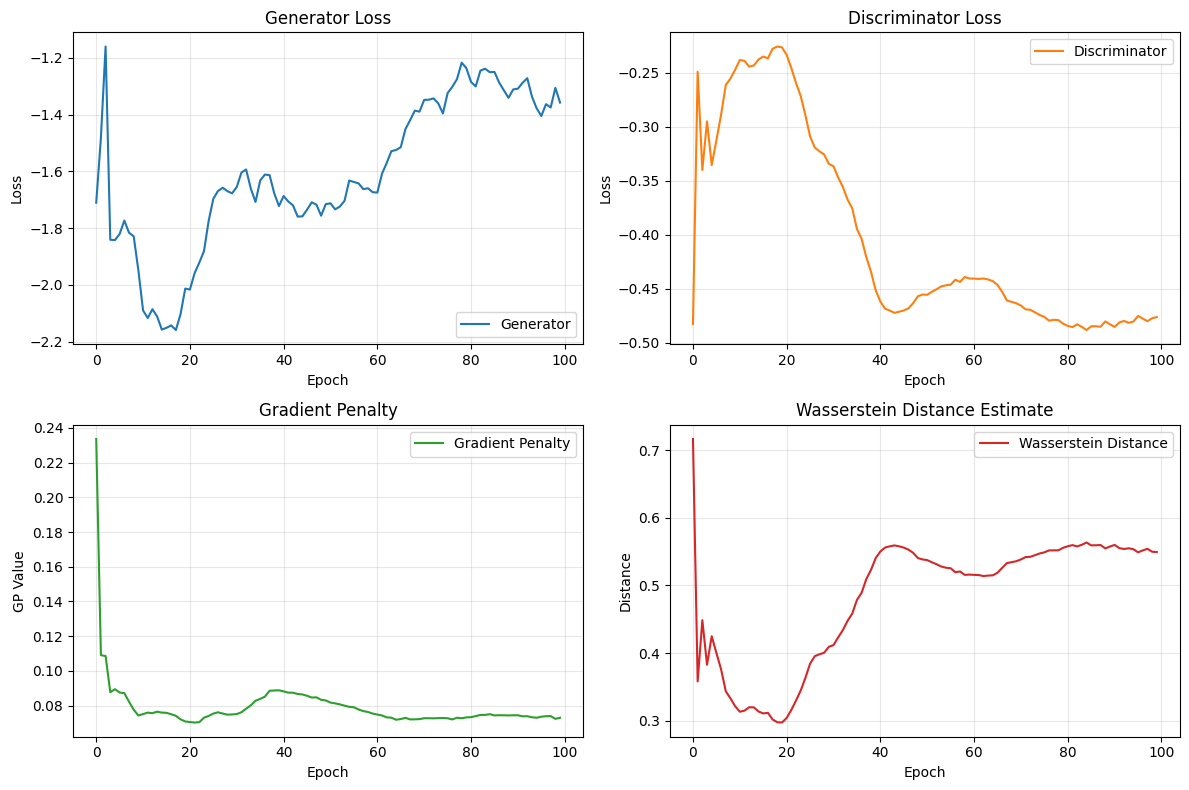

In [16]:
# ============================================================================
# 16. EVALUATION: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: VISUALIZATIONS")
print("="*80 + "\n")

# Plot training losses
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(result["history"]["g_loss"], label='Generator', color='tab:blue')
axes[0, 0].set_title("Generator Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(result["history"]["d_loss"], label='Discriminator', color='tab:orange')
axes[0, 1].set_title("Discriminator Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(result["history"]["gp"], label='Gradient Penalty', color='tab:green')
axes[1, 0].set_title("Gradient Penalty")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("GP Value")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(result["history"]["w_dist"], label='Wasserstein Distance', color='tab:red')
axes[1, 1].set_title("Wasserstein Distance Estimate")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Distance")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "training_metrics.png"), dpi=150, bbox_inches='tight')
plt.show()